In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Union, Tuple

from model_ranking.utils import (
    load_h5,
)

In [4]:
def get_ckpt_eval_scores(path: Union[str, Path], checkpoint_ids: List[int], eval_key: str = "F1_eval") -> Tuple[List[float], List[float]]:
    mean_eval_scores: List[float] = []
    median_eval_scores: List[float] = []
    if isinstance(path, str):
        path = Path(path)
    for id in checkpoint_ids:
        checkpoint_name = f"epoch-{int(id)}"
        summary_path = path / checkpoint_name / "predictions" / "metric_summary.h5"
        eval_score_pp = load_h5(summary_path, eval_key)
        eval_mean = load_h5(summary_path, f"{eval_key}_mean") 
        eval_median = load_h5(summary_path, f"{eval_key}_median")
        mean_eval_scores.append(eval_mean[1])
        median_eval_scores.append(eval_median[1])
        assert np.all(np.equal(np.mean(eval_score_pp, axis=0), eval_mean)), f"Eval mean mismatch for {checkpoint_name} {eval_mean} vs {np.mean(eval_score_pp, axis=0)}"
    return mean_eval_scores, median_eval_scores

# MeanTeacher Finetuning: DropOut Consistency Pseudolabeler

In [5]:
DO_mean_eval_scores, DO_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model1",
    list(range(2, 22, 2)),
)

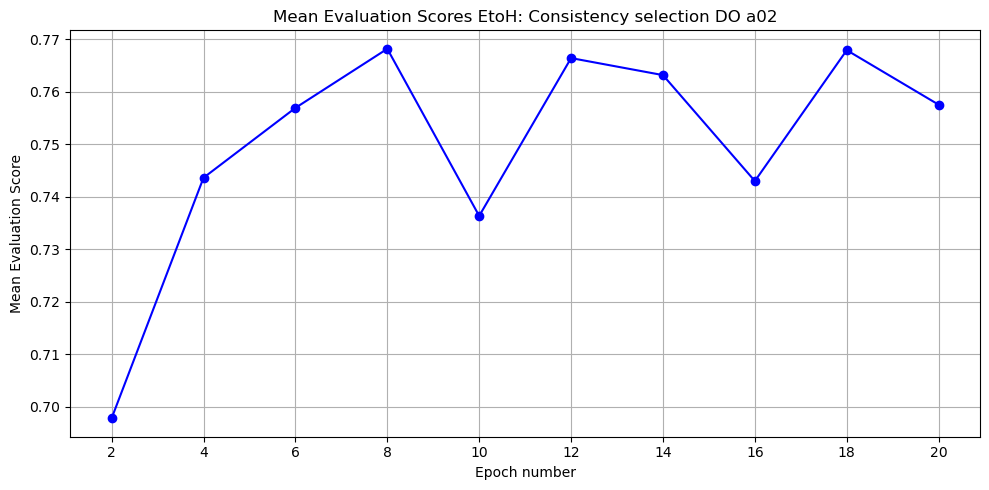

In [6]:
_ = plt.figure(figsize=(10, 5))
_ = plt.plot(list(range(2, 22, 2)), DO_mean_eval_scores, marker='o', linestyle='-', color='b')
_ =plt.title('Mean Evaluation Scores EtoH: Consistency selection DO a02')
_ =plt.xlabel('Epoch number')
_ =plt.ylabel('Mean Evaluation Score')
_ = plt.xticks(list(range(2, 22, 2)))
plt.grid()
plt.tight_layout()
#plt.savefig("mean_eval_scores_over_checkpoints.png")
plt.show()

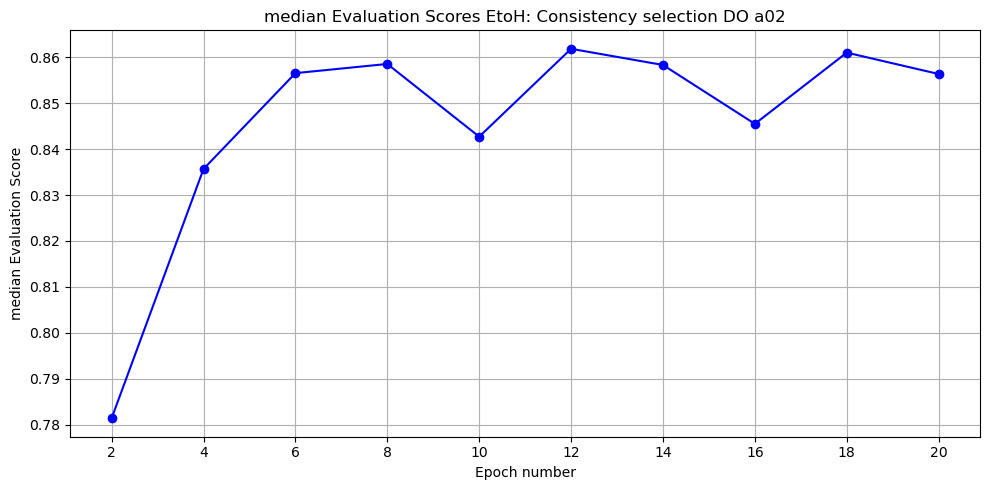

In [7]:
_ = plt.figure(figsize=(10, 5))
_ = plt.plot(list(range(2, 22, 2)), DO_median_eval_scores, marker='o', linestyle='-', color='b')
_ =plt.title('median Evaluation Scores EtoH: Consistency selection DO a02')
_ =plt.xlabel('Epoch number')
_ =plt.ylabel('median Evaluation Score')
_ = plt.xticks(list(range(2, 22, 2)))
plt.grid()
plt.tight_layout()
#plt.savefig("median_eval_scores_over_checkpoints.png")
plt.show()

# MeanTeacher Finetuning: Input Gaussian consistency Pseudolabeler

In [10]:
gauss_mean_eval_scores, gauss_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/input_perturbation/predictions/HtoE_gauss_a0-005_model1",
    list(range(2, 22, 2)),
)

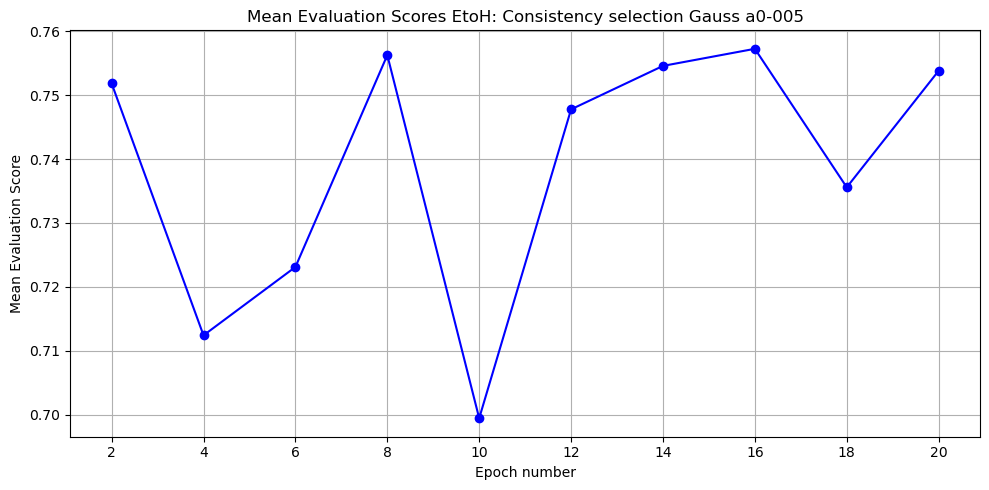

In [11]:
_ = plt.figure(figsize=(10, 5))
_ = plt.plot(list(range(2, 22, 2)), gauss_mean_eval_scores, marker='o', linestyle='-', color='b')
_ =plt.title('Mean Evaluation Scores EtoH: Consistency selection Gauss a0-005')
_ =plt.xlabel('Epoch number')
_ =plt.ylabel('Mean Evaluation Score')
_ = plt.xticks(list(range(2, 22, 2)))
plt.grid()
plt.tight_layout()
#plt.savefig("mean_eval_scores_over_checkpoints.png")
plt.show()

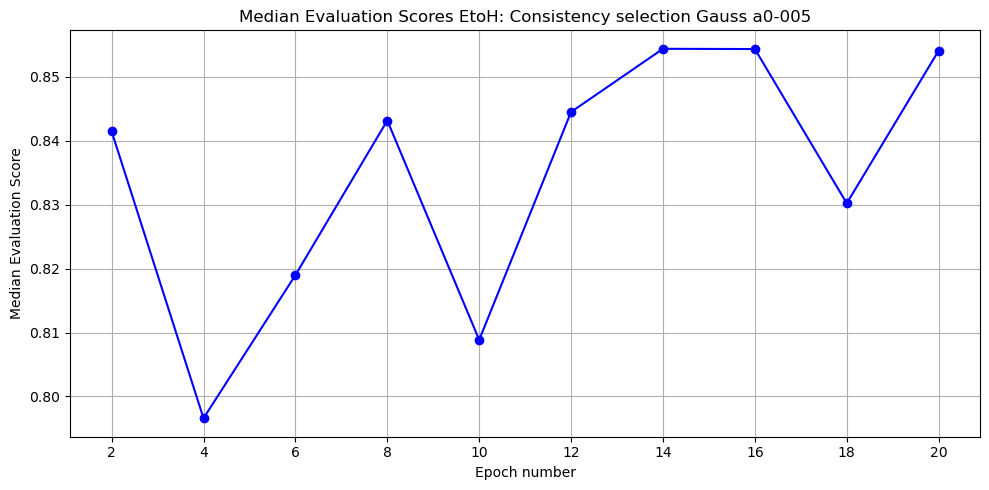

In [12]:
_ = plt.figure(figsize=(10, 5))
_ = plt.plot(list(range(2, 22, 2)), gauss_median_eval_scores, marker='o', linestyle='-', color='b')
_ =plt.title('Median Evaluation Scores EtoH: Consistency selection Gauss a0-005')
_ =plt.xlabel('Epoch number')
_ =plt.ylabel('Median Evaluation Score')
_ = plt.xticks(list(range(2, 22, 2)))
plt.grid()
plt.tight_layout()
#plt.savefig("mean_eval_scores_over_checkpoints.png")
plt.show()